## Trabalho Aprendizado de MÃƒÂ¡quina

#### Bibliotecas

In [69]:
# %pip install torch

In [1]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

/home/violetcoop/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import os
os.makedirs("figuras", exist_ok=True)

def save_fig(filename):
    plt.savefig(f"figuras/{filename}", dpi=150, bbox_inches='tight')

## Parte 1: Implementação de uma Rede Neural MLP e observação do Overfetting


In [3]:
class MLP(nn.Module):
    #define a rede
    def __init__(self, input_dim, hidden_dims, output_dim):
        # chama o construtor da classe pai - registra o modelo no Pytorch
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            # ReLU ÃƒÂ© adicionada entre as camadas, mas nunca depois da ÃƒÂºltima - a saÃƒÂ­da final nÃƒÂ£o tem ativaÃƒÂ§ÃƒÂ£o, a camada final jÃƒÂ¡ cuida disso
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [4]:
def train_model(model, train_loader, val_loader, optimizer, epochs, is_sam=False,
                patience=30, restore_best=True):
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, targets in train_loader:
            if is_sam:
                # 1) Move to the adversarial neighborhood.
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.first_step(zero_grad=True)

                # 2) Compute the gradient at the perturbed point and update the original point.
                outputs_second = model(inputs)
                loss_second = criterion(outputs_second, targets)
                loss_second.backward()
                optimizer.second_step(zero_grad=True)

                # Log the loss at the real final point, not at the perturbed SAM point.
                with torch.no_grad():
                    outputs_to_log = model(inputs)
                    loss_to_log = criterion(outputs_to_log, targets)
            else:
                optimizer.zero_grad()
                outputs_to_log = model(inputs)
                loss = criterion(outputs_to_log, targets)
                loss.backward()
                optimizer.step()
                loss_to_log = loss

            train_loss += loss_to_log.item()
            preds = (outputs_to_log > 0.0).float()
            train_correct += (preds == targets).sum().item()
            train_total += targets.size(0)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                preds = (outputs > 0.0).float()
                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_correct / train_total)
        history['val_acc'].append(val_correct / val_total)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                break

    if restore_best:
        model.load_state_dict(best_state)

    history['best_val_loss'] = best_val_loss
    history['epochs_trained'] = len(history['train_loss'])
    history['restore_best'] = restore_best
    return history

In [5]:
def evaluate_model(model, loader):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            preds = (outputs > 0.0).float()
            total_loss += loss.item()
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    return {
        'loss': total_loss / len(loader),
        'accuracy': correct / total,
    }

def summarize_model(name, model):
    train_metrics = evaluate_model(model, train_loader_tit)
    val_metrics = evaluate_model(model, val_loader_tit)
    test_metrics = evaluate_model(model, test_loader_tit)
    gap = train_metrics['accuracy'] - test_metrics['accuracy']

    print(f"{name}")
    print(f"  train loss: {train_metrics['loss']:.4f} | train acc: {train_metrics['accuracy']:.3f}")
    print(f"  val   loss: {val_metrics['loss']:.4f} | val   acc: {val_metrics['accuracy']:.3f}")
    print(f"  test  loss: {test_metrics['loss']:.4f} | test  acc: {test_metrics['accuracy']:.3f}")
    print(f"  generalization gap (train_acc - test_acc): {gap:.3f}")
    return {'train': train_metrics, 'val': val_metrics, 'test': test_metrics, 'gap': gap}

### Pré Processamento dos Dados

#### Titanic

In [6]:
df_titanic = pd.read_csv("dados/Titanic/Titanic-Dataset.csv")
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
# Separar target e remover colunas identificadoras antes do split.
# A imputacao/normalizacao/codificacao sera ajustada somente no treino.
df_titanic_model = df_titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']).copy()

X = df_titanic_model.drop(columns=['Survived'])
y = df_titanic_model['Survived'].astype(float)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED,
)

numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Sex', 'Embarked']

age_median = X_train_raw['Age'].median()
fare_median = X_train_raw['Fare'].median()
embarked_mode = X_train_raw['Embarked'].mode()[0]


def preprocess_titanic_split(split):
    split = split.copy()
    split['Age'] = split['Age'].fillna(age_median)
    split['Fare'] = split['Fare'].fillna(fare_median)
    split['Embarked'] = split['Embarked'].fillna(embarked_mode)
    split = pd.get_dummies(split, columns=categorical_cols, drop_first=True)
    return split.astype(float)

X_train_pre = preprocess_titanic_split(X_train_raw)
X_val_pre = preprocess_titanic_split(X_val_raw).reindex(columns=X_train_pre.columns, fill_value=0.0)
X_test_pre = preprocess_titanic_split(X_test_raw).reindex(columns=X_train_pre.columns, fill_value=0.0)

X_train_pre.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
844,3.0,17.0,0.0,0.0,8.6625,1.0,0.0,1.0
316,2.0,24.0,1.0,0.0,26.0000,0.0,0.0,1.0
768,3.0,29.0,1.0,0.0,24.1500,1.0,1.0,0.0
255,3.0,29.0,0.0,2.0,15.2458,0.0,0.0,0.0
130,3.0,33.0,0.0,0.0,7.8958,1.0,0.0,0.0


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pre)
X_val_scaled = scaler.transform(X_val_pre)
X_test_scaled = scaler.transform(X_test_pre)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

batch_size = 32
train_loader_tit = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader_tit = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
test_loader_tit = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

input_dim_tit = X_train_tensor.shape[1]
print(f"Features usadas no Titanic: {list(X_train_pre.columns)}")
print(f"input_dim = {input_dim_tit}")

Features usadas no Titanic: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
input_dim = 8


### Treinamento

In [9]:
set_seed(42)
modelo_adam = MLP(input_dim=input_dim_tit, hidden_dims=[64, 32], output_dim=1)
otimizador_adam = optim.Adam(modelo_adam.parameters(), lr=0.001, weight_decay=1e-4)
epocas = 300

print("Iniciando o treinamento com Adam...")
historico_adam = train_model(
    model=modelo_adam,
    train_loader=train_loader_tit,
    val_loader=val_loader_tit,
    optimizer=otimizador_adam,
    epochs=epocas,
    is_sam=False,
    patience=40,
)
print(f"Treinamento Adam concluido em {historico_adam['epochs_trained']} epocas.")

Iniciando o treinamento com Adam...
Treinamento Adam concluido em 72 epocas.


In [10]:
metricas_adam = summarize_model("Adam", modelo_adam)

Adam
  train loss: 0.3799 | train acc: 0.846
  val   loss: 0.3854 | val   acc: 0.848
  test  loss: 0.4313 | test  acc: 0.810
  generalization gap (train_acc - test_acc): 0.036


Visualização de Overfitting

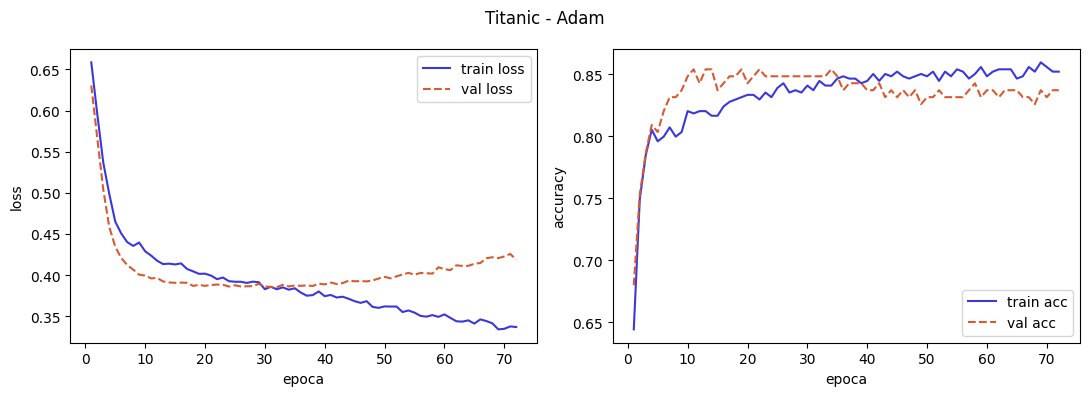

In [11]:
def plot_history(history, title=""):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history['train_loss'], label='train loss', color="#3A37DD")
    axes[0].plot(epochs, history['val_loss'], label='val loss', color='#D85A30', linestyle='--')
    axes[0].set_xlabel('epoca')
    axes[0].set_ylabel('loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='train acc', color="#3A37DD")
    axes[1].plot(epochs, history['val_acc'], label='val acc', color='#D85A30', linestyle='--')
    axes[1].set_xlabel('epoca')
    axes[1].set_ylabel('accuracy')
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_history(historico_adam, title="Titanic - Adam")

## Observação do autovalor da Hessiana e Ligação com Overfitting

In [12]:
def calcular_gap_generalizacao(train_loss, val_loss):
    # Um gap positivo muito alto indica overfitting
    return val_loss - train_loss

In [13]:
def calcular_autovalor_dominante_full(inputs, targets, model, criterion,
                                      num_iterations=10, seed=None):
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)

    num_params = sum(p.numel() for p in model.parameters())
    v = torch.randn(num_params, device=inputs.device)
    v = v / torch.norm(v)
    history_eigenvalues = []

    for i in range(num_iterations):
        model.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
        flat_grads = torch.cat([g.contiguous().view(-1) for g in grads])
        grad_v_prod = torch.dot(flat_grads, v)
        hvp = torch.autograd.grad(grad_v_prod, model.parameters())
        flat_hvp = torch.cat([h.contiguous().view(-1) for h in hvp])

        eigenvalue = torch.dot(v, flat_hvp).item()
        history_eigenvalues.append(eigenvalue)

        hvp_norm = torch.norm(flat_hvp)
        if hvp_norm.item() < 1e-12:
            break
        v = flat_hvp / hvp_norm

    return history_eigenvalues, v.detach()

### SAM

In [14]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        assert rho >= 0.0, f"O valor de rho deve ser nÃƒÂ£o-negativo: {rho}"

        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)

        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        # Passo 1: Encontra a direÃƒÂ§ÃƒÂ£o de maior subida (adversarial)
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale
                p.add_(e_w)  # Sobe o morro (direÃƒÂ§ÃƒÂ£o adversarial)
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        # Passo 2: Volta para o ponto original e aplica o gradiente calculado lÃƒÂ¡ de cima
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])  # Retorna ao ponto original

        self.base_optimizer.step()  # Atualiza os pesos de verdade
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        # Calcula a norma do gradiente de todos os parÃƒÂ¢metros
        norm = torch.norm(
            torch.stack([
                p.grad.norm(p=2)
                for group in self.param_groups for p in group["params"]
                if p.grad is not None
            ]),
            p=2
        )
        return norm

In [15]:
set_seed(42)
modelo_sam = MLP(input_dim=input_dim_tit, hidden_dims=[64, 32], output_dim=1)

# Comparacao direta com Adam: o otimizador base do SAM tambem e Adam.
otimizador_sam = SAM(modelo_sam.parameters(), base_optimizer=optim.Adam, lr=0.001, weight_decay=1e-4, rho=0.05)

print("Iniciando o treinamento com SAM + Adam...")
historico_sam = train_model(
    model=modelo_sam,
    train_loader=train_loader_tit,
    val_loader=val_loader_tit,
    optimizer=otimizador_sam,
    epochs=epocas,
    is_sam=True,
    patience=40,
)
print(f"Treinamento SAM concluido em {historico_sam['epochs_trained']} epocas.")
metricas_sam = summarize_model("SAM + Adam", modelo_sam)

Iniciando o treinamento com SAM + Adam...
Treinamento SAM concluido em 72 epocas.
SAM + Adam
  train loss: 0.3831 | train acc: 0.845
  val   loss: 0.3869 | val   acc: 0.848
  test  loss: 0.4310 | test  acc: 0.821
  generalization gap (train_acc - test_acc): 0.023


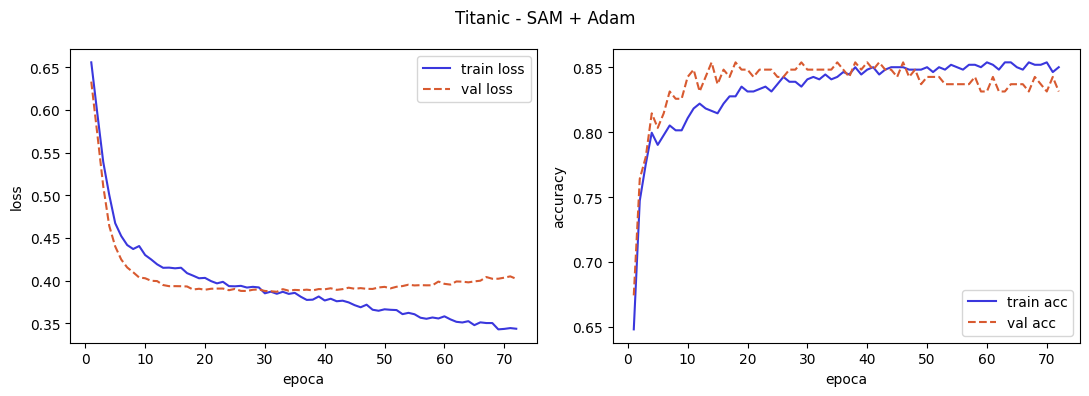

In [16]:
plot_history(historico_sam, title="Titanic - SAM + Adam")

## Experimento de Correlação: λ_max ↔ Gap de Generalização

Para validar que λ_max *prediz* overfitting (e não apenas coexiste com ele
no caso Adam vs. SAM), treinamos 4 modelos com graus deliberadamente
distintos de sobreajuste. A hipótese é que a ordenação por λ_max deve
coincidir com a ordenação pelo gap de generalização.

As três alavancas de overfitting usadas são:
- **Capacidade**: mais neurônios/camadas → modelo consegue memorizar mais
- **Regularização L2** (weight_decay): sem penalidade nos pesos → pesos grandes, curvatura maior
- **Early stopping desativado**: treina até convergência total → memoriza o ruído

In [17]:
def get_lambda_max(model, inputs, targets, criterion, num_iterations=30, seed=None):
    """Return only the final lambda_max scalar, convenient for experiment loops."""
    history, _ = calcular_autovalor_dominante_full(
        inputs, targets, model, criterion,
        num_iterations=num_iterations,
        seed=seed,
    )
    return history[-1]


# Main experiment: rho ablation with multiple seeds.
# Everything below is fixed except rho and initialization seed.
SEEDS_EXPERIMENTO = [0, 1, 2, 3, 4]
RHO_VALUES = [None, 0.001, 0.01, 0.05, 0.1, 0.5]
BASE_HIDDEN_DIMS = [64, 32]
BASE_LR = 0.001
BASE_WEIGHT_DECAY = 1e-4
BASE_EPOCHS = 300
BASE_PATIENCE = 40
BASE_RESTORE_BEST = True


def format_rho_label(rho):
    if rho is None:
        return 'Adam'
    return f'SAM rho={rho:g}'


configuracoes_rho = [
    {
        'nome': format_rho_label(rho),
        'rho': rho,
        'is_sam': rho is not None,
    }
    for rho in RHO_VALUES
]

In [ ]:
resultados_rho = []
modelos_representativos = {}
criterion = nn.BCEWithLogitsLoss()

for seed in SEEDS_EXPERIMENTO:
    print(f"\n{'#'*70}")
    print(f"SEED {seed}")
    print(f"{'#'*70}")

    for cfg in configuracoes_rho:
        nome = cfg['nome']
        rho = cfg['rho']
        is_sam = cfg['is_sam']

        print(f"\n--- {nome} ---")
        set_seed(seed)
        model = MLP(input_dim=input_dim_tit, hidden_dims=BASE_HIDDEN_DIMS, output_dim=1)

        # Recreate the training loader for every configuration. This keeps the
        # mini-batch order identical across Adam/SAM for the same seed.
        train_generator = torch.Generator().manual_seed(seed)
        train_loader_seed = DataLoader(
            TensorDataset(X_train_tensor, y_train_tensor),
            batch_size=batch_size,
            shuffle=True,
            generator=train_generator,
        )

        if is_sam:
            optimizer = SAM(
                model.parameters(),
                base_optimizer=optim.Adam,
                lr=BASE_LR,
                weight_decay=BASE_WEIGHT_DECAY,
                rho=rho,
            )
        else:
            optimizer = optim.Adam(
                model.parameters(),
                lr=BASE_LR,
                weight_decay=BASE_WEIGHT_DECAY,
            )

        history = train_model(
            model=model,
            train_loader=train_loader_seed,
            val_loader=val_loader_tit,
            optimizer=optimizer,
            epochs=BASE_EPOCHS,
            is_sam=is_sam,
            patience=BASE_PATIENCE,
            restore_best=BASE_RESTORE_BEST,
        )

        train_m = evaluate_model(model, train_loader_tit)
        val_m = evaluate_model(model, val_loader_tit)
        test_m = evaluate_model(model, test_loader_tit)

        gap_loss = test_m['loss'] - train_m['loss']
        gap_acc = train_m['accuracy'] - test_m['accuracy']

        lam = get_lambda_max(
            model,
            X_train_tensor,
            y_train_tensor,
            criterion,
            num_iterations=30,
            seed=seed,
        )

        print(f"epochs={history['epochs_trained']:>3} | train_loss={train_m['loss']:.4f} | test_loss={test_m['loss']:.4f} | gap_loss={gap_loss:+.4f} | lambda_max={lam:.4f}")

        resultados_rho.append({
            'seed': seed,
            'nome': nome,
            'rho': 'Adam' if rho is None else rho,
            'rho_value': np.nan if rho is None else rho,
            'is_sam': is_sam,
            'epochs': history['epochs_trained'],
            'train_loss': train_m['loss'],
            'val_loss': val_m['loss'],
            'test_loss': test_m['loss'],
            'train_acc': train_m['accuracy'],
            'val_acc': val_m['accuracy'],
            'test_acc': test_m['accuracy'],
            'gap_loss': gap_loss,
            'gap_acc': gap_acc,
            'lambda_max': lam,
        })

        # Keep one representative model per configuration for the geometry plots.
        if seed == SEEDS_EXPERIMENTO[0]:
            modelos_representativos[nome] = copy.deepcopy(model)


######################################################################
SEED 0
######################################################################

--- Adam ---
epochs= 61 | train_loss=0.3874 | test_loss=0.4137 | gap_loss=+0.0263 | lambda_max=1.9754

--- SAM rho=0.001 ---
epochs= 61 | train_loss=0.3876 | test_loss=0.4143 | gap_loss=+0.0268 | lambda_max=1.9646

--- SAM rho=0.01 ---
epochs= 61 | train_loss=0.3882 | test_loss=0.4141 | gap_loss=+0.0259 | lambda_max=1.8857

--- SAM rho=0.05 ---
epochs= 61 | train_loss=0.3902 | test_loss=0.4152 | gap_loss=+0.0249 | lambda_max=1.6052

--- SAM rho=0.1 ---
epochs= 59 | train_loss=0.4020 | test_loss=0.4195 | gap_loss=+0.0175 | lambda_max=1.2806

--- SAM rho=0.5 ---
epochs= 86 | train_loss=0.3888 | test_loss=0.4251 | gap_loss=+0.0363 | lambda_max=0.5639

######################################################################
SEED 1
######################################################################

--- Adam ---
epochs= 55 | train_loss=0.396

In [88]:
df_rho = pd.DataFrame(resultados_rho)

colunas_tabela = [
    'seed', 'nome', 'epochs',
    'train_loss', 'test_loss', 'gap_loss',
    'train_acc', 'test_acc', 'gap_acc',
    'lambda_max',
]

print("Per-seed results:")
print(
    df_rho[colunas_tabela]
    .sort_values(['nome', 'seed'])
    .to_string(index=False, formatters={
        'train_loss': '{:.4f}'.format,
        'test_loss': '{:.4f}'.format,
        'gap_loss': '{:+.4f}'.format,
        'train_acc': '{:.3f}'.format,
        'test_acc': '{:.3f}'.format,
        'gap_acc': '{:+.3f}'.format,
        'lambda_max': '{:.4f}'.format,
    })
)

summary_rho = (
    df_rho
    .groupby('nome', sort=False)
    .agg(
        lambda_mean=('lambda_max', 'mean'),
        lambda_std=('lambda_max', 'std'),
        gap_loss_mean=('gap_loss', 'mean'),
        gap_loss_std=('gap_loss', 'std'),
        test_loss_mean=('test_loss', 'mean'),
        test_loss_std=('test_loss', 'std'),
        test_acc_mean=('test_acc', 'mean'),
        test_acc_std=('test_acc', 'std'),
        epochs_mean=('epochs', 'mean'),
    )
    .reset_index()
)

print("\nMean +/- std by configuration:")
for _, row in summary_rho.iterrows():
    print(
        f"{row['nome']:<14} "
        f"lambda={row['lambda_mean']:.4f} +/- {row['lambda_std']:.4f} | "
        f"gap_loss={row['gap_loss_mean']:+.4f} +/- {row['gap_loss_std']:.4f} | "
        f"test_acc={row['test_acc_mean']:.3f} +/- {row['test_acc_std']:.3f}"
    )

Per-seed results:
 seed          nome  epochs train_loss test_loss gap_loss train_acc test_acc gap_acc lambda_max
    0          Adam      61     0.3874    0.4137  +0.0263     0.843    0.821  +0.021     1.9754
    1          Adam      55     0.3969    0.4285  +0.0316     0.831    0.821  +0.010     1.8153
    2          Adam      60     0.3916    0.4248  +0.0332     0.837    0.827  +0.010     2.1921
    3          Adam      56     0.3964    0.4339  +0.0375     0.839    0.816  +0.023     1.9100
    4          Adam      64     0.3843    0.4202  +0.0359     0.841    0.827  +0.014     2.3888
    0 SAM rho=0.001      61     0.3876    0.4143  +0.0268     0.845    0.821  +0.023     1.9646
    1 SAM rho=0.001      55     0.3969    0.4284  +0.0315     0.835    0.821  +0.014     1.8018
    2 SAM rho=0.001      69     0.3801    0.4261  +0.0460     0.843    0.838  +0.005     2.2431
    3 SAM rho=0.001      56     0.3965    0.4341  +0.0376     0.839    0.816  +0.023     1.8952
    4 SAM rho=0.001   

/tmp/ipykernel_1488/2960947931.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(lambda_data, labels=labels, showmeans=True)
/tmp/ipykernel_1488/2960947931.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(gap_data, labels=labels, showmeans=True)


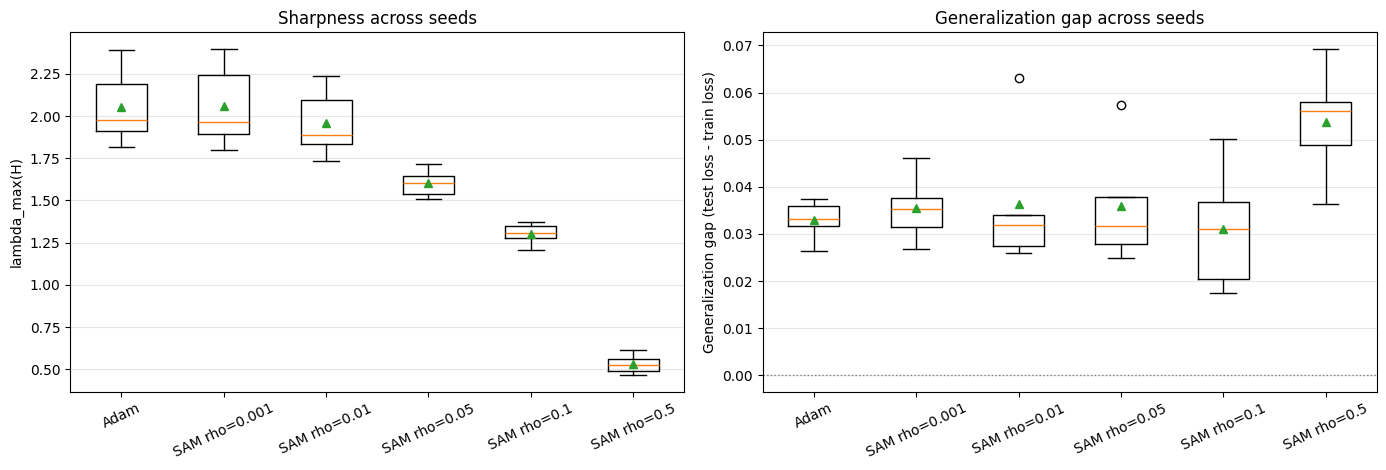

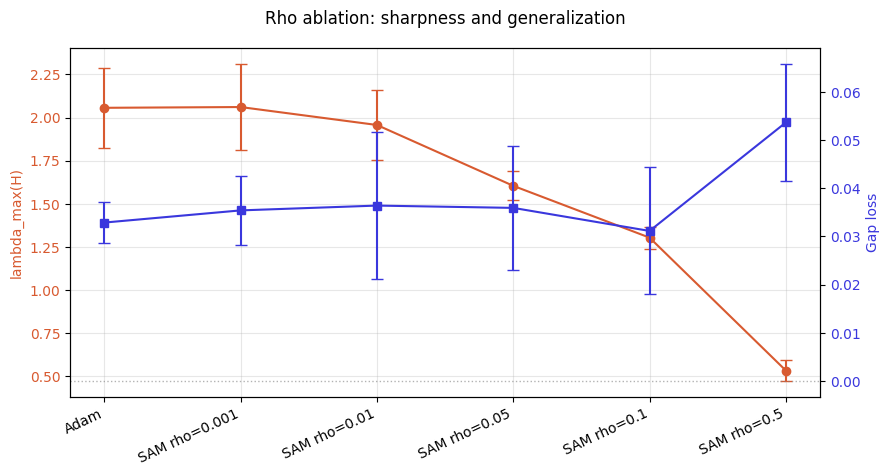

Important reading:
- Adam is the baseline optimizer.
- Every SAM model uses Adam as base_optimizer; rho is the only SAM-specific variable changed.
- If lambda intervals overlap, the effect is not robust under these seeds.
- If lambda decreases but gap does not, that disagreement is a valid experimental finding.


In [89]:
labels = list(summary_rho['nome'])
positions = np.arange(len(labels))

lambda_data = [df_rho.loc[df_rho['nome'] == label, 'lambda_max'].values for label in labels]
gap_data = [df_rho.loc[df_rho['nome'] == label, 'gap_loss'].values for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Boxplot: lambda_max distribution across seeds.
axes[0].boxplot(lambda_data, labels=labels, showmeans=True)
axes[0].set_ylabel('lambda_max(H)')
axes[0].set_title('Sharpness across seeds')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=25)

# Boxplot: loss gap distribution across seeds.
axes[1].boxplot(gap_data, labels=labels, showmeans=True)
axes[1].axhline(0.0, color='gray', linestyle=':', linewidth=1)
axes[1].set_ylabel('Generalization gap (test loss - train loss)')
axes[1].set_title('Generalization gap across seeds')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=25)

fig.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(9, 4.8))

lambda_mean = summary_rho['lambda_mean'].values
lambda_std = summary_rho['lambda_std'].values
gap_mean = summary_rho['gap_loss_mean'].values
gap_std = summary_rho['gap_loss_std'].values

ax1.errorbar(positions, lambda_mean, yerr=lambda_std, marker='o', capsize=4,
             color='#D85A30', label='lambda_max mean +/- std')
ax1.set_ylabel('lambda_max(H)', color='#D85A30')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=25, ha='right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.errorbar(positions, gap_mean, yerr=gap_std, marker='s', capsize=4,
             color='#3A37DD', label='gap_loss mean +/- std')
ax2.set_ylabel('Gap loss', color='#3A37DD')
ax2.tick_params(axis='y', labelcolor='#3A37DD')
ax2.axhline(0.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)

fig.suptitle('Rho ablation: sharpness and generalization')
fig.tight_layout()
plt.show()

print("Important reading:")
print("- Adam is the baseline optimizer.")
print("- Every SAM model uses Adam as base_optimizer; rho is the only SAM-specific variable changed.")
print("- If lambda intervals overlap, the effect is not robust under these seeds.")
print("- If lambda decreases but gap does not, that disagreement is a valid experimental finding.")

### Gráfico de Convergência

Calculando convergência para o Adam puro...
Calculando convergência para o SAM + Adam...


<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1488/4191466032.py:35: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Gráfico de Convergência do Método da Potência ($\lambda_{max}$)", fontsize=12)
/tmp/ipykernel_1488/4191466032.py:37: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Estimativa de $\lambda_{max}(H)$", fontsize=10)


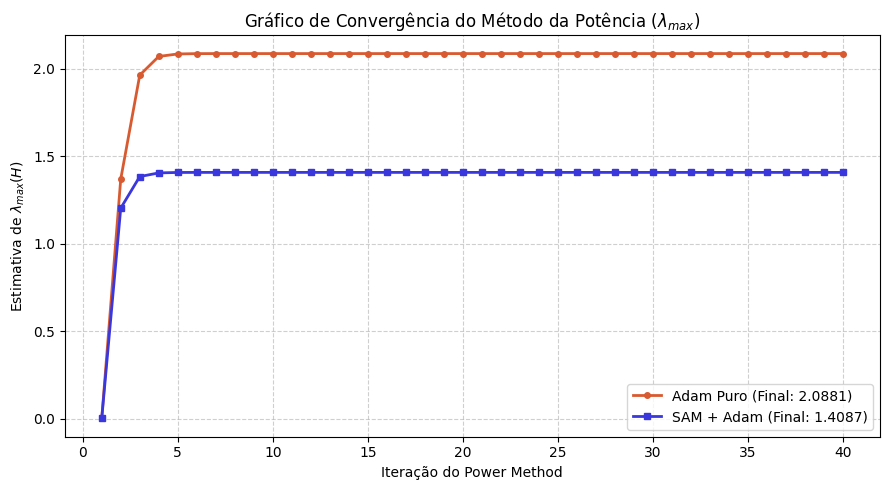

In [90]:
# Executa o método coletando o histórico completo
iterations = 40
criterion = nn.BCEWithLogitsLoss()
print("Calculando convergência para o Adam puro...")
historico_lambda_adam, v_adam = calcular_autovalor_dominante_full(
    X_train_tensor, y_train_tensor, modelo_adam, criterion, iterations
)

print("Calculando convergência para o SAM + Adam...")
historico_lambda_sam, v_sam = calcular_autovalor_dominante_full(
    X_train_tensor, y_train_tensor, modelo_sam, criterion, iterations
)

# Plotagem do Gráfico de Análise Metodológica
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, iterations + 1),
    historico_lambda_adam,
    label=f"Adam Puro (Final: {historico_lambda_adam[-1]:.4f})",
    color="#D85A30",
    linewidth=2,
    marker="o",
    markersize=4,
)
plt.plot(
    range(1, iterations + 1),
    historico_lambda_sam,
    label=f"SAM + Adam (Final: {historico_lambda_sam[-1]:.4f})",
    color="#3A37DD",
    linewidth=2,
    marker="s",
    markersize=4,
)

plt.title("Gráfico de Convergência do Método da Potência ($\lambda_{max}$)", fontsize=12)
plt.xlabel("Iteração do Power Method", fontsize=10)
plt.ylabel("Estimativa de $\lambda_{max}(H)$", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)

# Garantir limites visuais limpos
plt.tight_layout()
plt.show()

### Experimento Perturbação

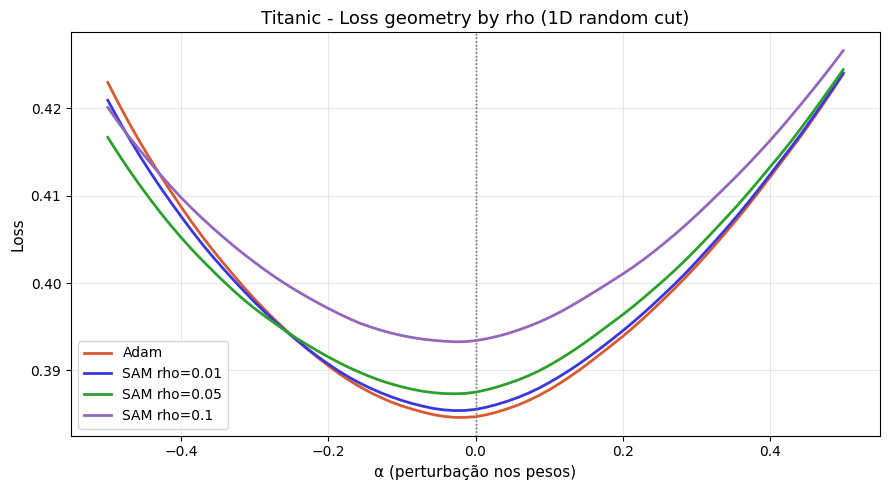

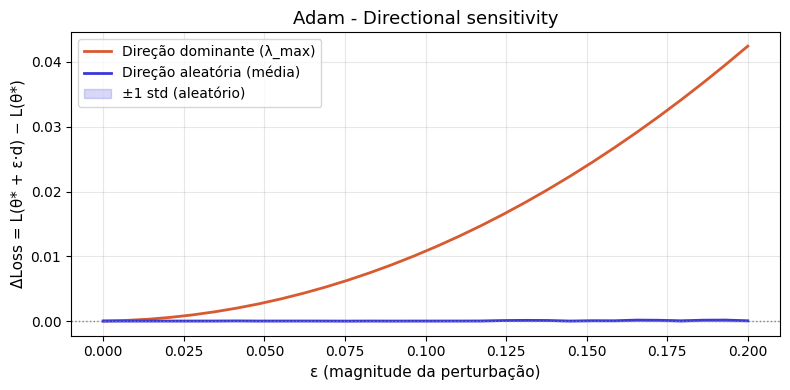

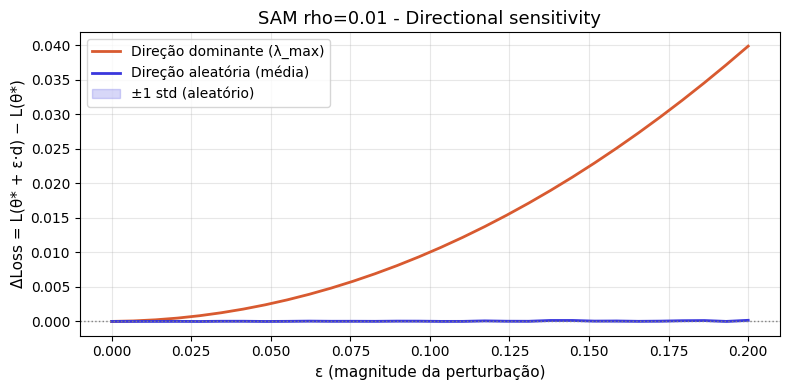

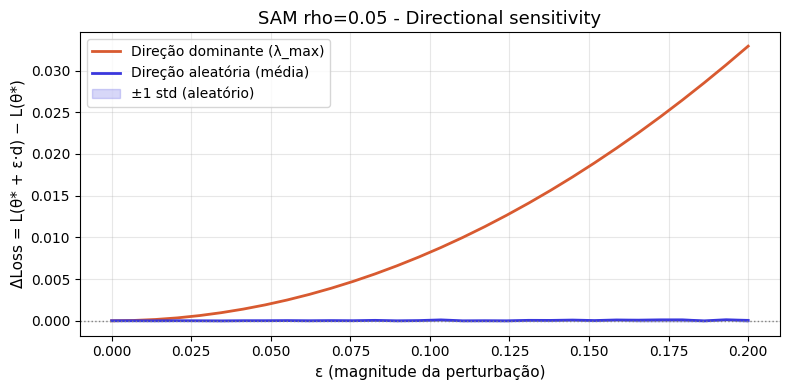

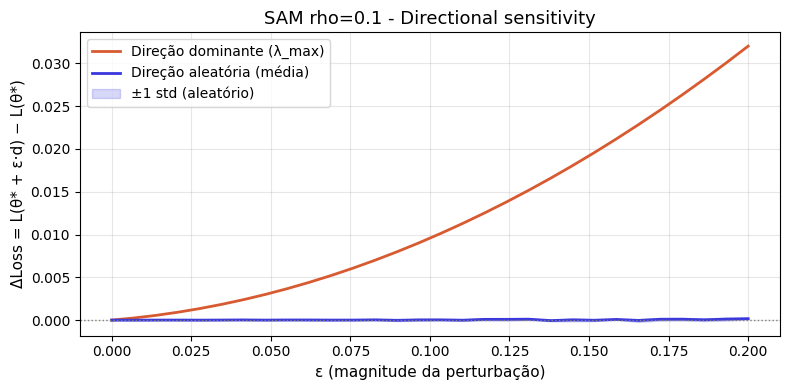

In [91]:
import sys
sys.path.append('.')
from loss_geometria import compare_models_1d, perturbation_experiment
from loss_geometria import compute_loss_landscape_2d, plot_landscape_2d

criterion = nn.BCEWithLogitsLoss()

# Representative models use the first seed from SEEDS_EXPERIMENTO.
# Adam is pure Adam. Every SAM model below uses Adam as base_optimizer.
modelos_geometria = {
    'Adam': modelos_representativos['Adam'],
    'SAM rho=0.01': modelos_representativos['SAM rho=0.01'],
    'SAM rho=0.05': modelos_representativos['SAM rho=0.05'],
    'SAM rho=0.1': modelos_representativos['SAM rho=0.1'],
}

compare_models_1d(
    models_dict=modelos_geometria,
    inputs=X_train_tensor,
    targets=y_train_tensor,
    criterion=criterion,
    alphas=np.linspace(-0.5, 0.5, 71),
    title='Titanic - Loss geometry by rho (1D random cut)'
)

for nome, modelo in modelos_geometria.items():
    perturbation_experiment(
        modelo,
        X_train_tensor,
        y_train_tensor,
        criterion,
        epsilons=np.linspace(0, 0.2, 30),
        n_trials=5,
        title=f'{nome} - Directional sensitivity'
    )

Computing surface: Adam
  Progresso: 100/900
  Progresso: 200/900
  Progresso: 300/900
  Progresso: 400/900
  Progresso: 500/900
  Progresso: 600/900
  Progresso: 700/900
  Progresso: 800/900
  Progresso: 900/900
Computing surface: SAM rho=0.5
  Progresso: 100/900
  Progresso: 200/900
  Progresso: 300/900
  Progresso: 400/900
  Progresso: 500/900
  Progresso: 600/900
  Progresso: 700/900
  Progresso: 800/900
  Progresso: 900/900


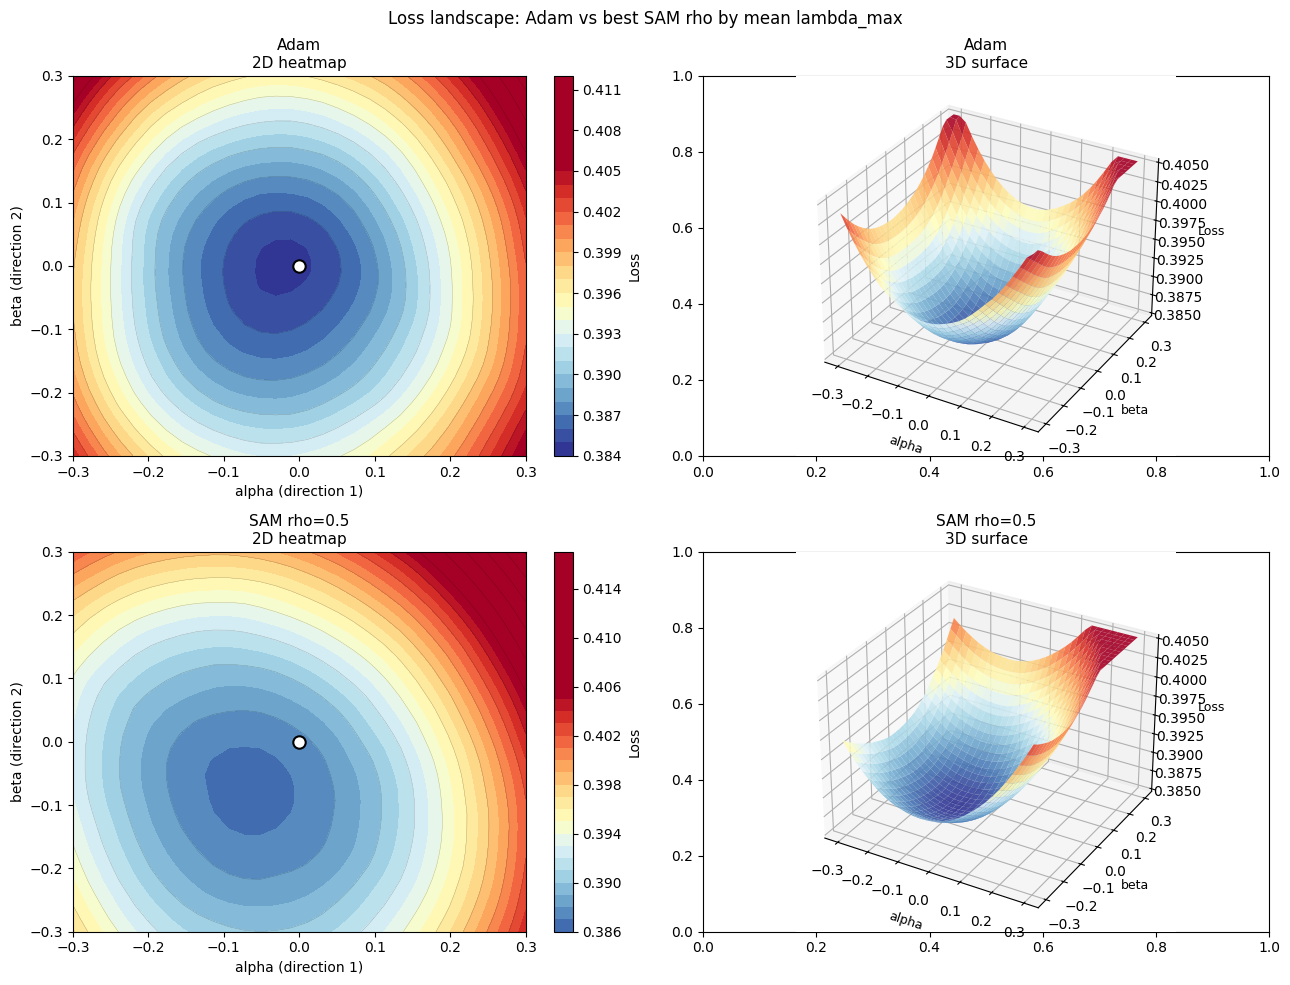

In [92]:
from loss_geometria import compute_loss_landscape_2d
import matplotlib.pyplot as plt
import numpy as np

criterion = nn.BCEWithLogitsLoss()

# Compare two models with the SAME architecture and SAME base optimizer family.
# Difference: Adam baseline vs SAM with the rho that produced the lowest mean lambda_max.
sam_summary = summary_rho[summary_rho['nome'] != 'Adam'].copy()
best_sam_name = sam_summary.sort_values('lambda_mean').iloc[0]['nome']

modelo_adam_rep = modelos_representativos['Adam']
modelo_sam_rep = modelos_representativos[best_sam_name]

alphas_zoom = np.linspace(-0.3, 0.3, 30)
betas_zoom  = np.linspace(-0.3, 0.3, 30)

print(f"Computing surface: Adam")
grid_adam = compute_loss_landscape_2d(
    modelo_adam_rep, X_train_tensor, y_train_tensor, criterion,
    alphas=alphas_zoom, betas=betas_zoom,
)

print(f"Computing surface: {best_sam_name}")
grid_sam = compute_loss_landscape_2d(
    modelo_sam_rep, X_train_tensor, y_train_tensor, criterion,
    alphas=alphas_zoom, betas=betas_zoom,
)

vmin_global = min(grid_adam.min(), grid_sam.min())
vmax_global = max(
    np.percentile(grid_adam, 95),
    np.percentile(grid_sam, 95),
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (grid, nome) in enumerate([
    (grid_adam, 'Adam'),
    (grid_sam, best_sam_name),
]):
    ax_h = axes[row, 0]
    im = ax_h.contourf(alphas_zoom, betas_zoom, grid,
                       levels=30, cmap='RdYlBu_r',
                       vmin=vmin_global, vmax=vmax_global)
    ax_h.contour(alphas_zoom, betas_zoom, grid,
                 levels=15, colors='black', linewidths=0.3, alpha=0.3)
    ax_h.scatter([0], [0], color='white', s=80, zorder=5,
                 edgecolors='black', linewidths=1.5)
    ax_h.set_xlabel('alpha (direction 1)', fontsize=10)
    ax_h.set_ylabel('beta (direction 2)', fontsize=10)
    ax_h.set_title(f'{nome}\n2D heatmap', fontsize=11)
    plt.colorbar(im, ax=ax_h, label='Loss')

    ax_3 = fig.add_subplot(2, 2, row * 2 + 2, projection='3d')
    A, B = np.meshgrid(alphas_zoom, betas_zoom)
    Z = np.clip(grid, vmin_global, vmax_global)
    ax_3.plot_surface(A, B, Z, cmap='RdYlBu_r',
                      linewidth=0, antialiased=True, alpha=0.9)
    ax_3.set_zlim(vmin_global, vmax_global)
    ax_3.set_xlabel('alpha', fontsize=9)
    ax_3.set_ylabel('beta', fontsize=9)
    ax_3.set_zlabel('Loss', fontsize=9)
    ax_3.set_title(f'{nome}\n3D surface', fontsize=11)
    ax_3.view_init(elev=30, azim=-60)

fig.suptitle('Loss landscape: Adam vs best SAM rho by mean lambda_max')
fig.tight_layout()
plt.show()

### Experimento com diversos rhos

### Sharpness over time

  Época 10: λ_max = 1.8530
  Época 20: λ_max = 1.9500
  Época 30: λ_max = 2.0574
  Época 40: λ_max = 2.1783
  Época 50: λ_max = 2.3643
  Época 60: λ_max = 2.5642
  Early stopping na época 66.
  Época 10: λ_max = 1.4780
  Época 20: λ_max = 1.4183
  Época 30: λ_max = 1.4102
  Época 40: λ_max = 1.3984
  Época 50: λ_max = 1.4042
  Época 60: λ_max = 1.4052
  Época 70: λ_max = 1.4272
  Early stopping na época 76.


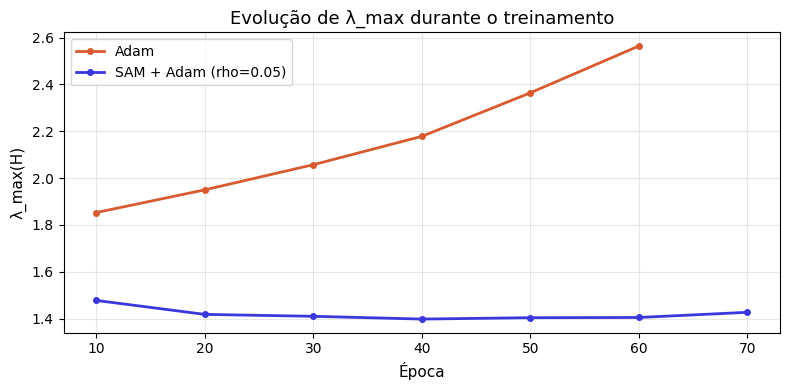

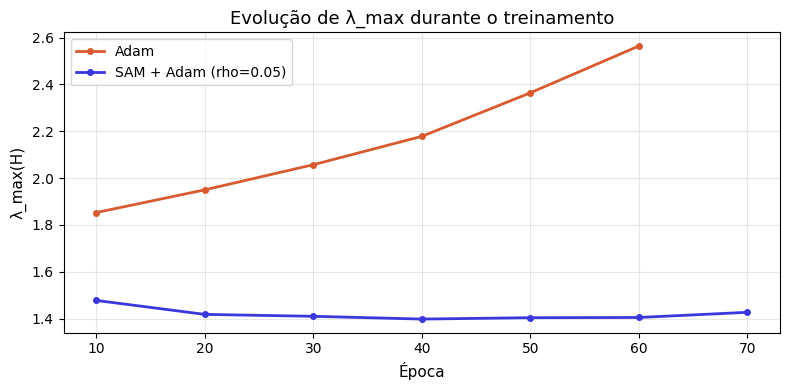

In [93]:
from loss_geometria import train_with_sharpness_tracking, plot_sharpness_over_time

set_seed(42)
modelo_adam_track = MLP(input_dim=input_dim_tit, hidden_dims=[64, 32], output_dim=1)
otimizador_adam_track = optim.Adam(modelo_adam_track.parameters(), lr=0.001, weight_decay=1e-4)

historico_adam_track = train_with_sharpness_tracking(
    model=modelo_adam_track,
    train_loader=train_loader_tit,
    val_loader=val_loader_tit,
    optimizer=otimizador_adam_track,
    criterion=nn.BCEWithLogitsLoss(),
    epochs=300,
    is_sam=False,
    patience=40,
    track_every=10,          # computes λ_max every 10 epochs
    X_full=X_train_tensor,
    y_full=y_train_tensor,
)

set_seed(42)
modelo_sam_track = MLP(input_dim=input_dim_tit, hidden_dims=[64, 32], output_dim=1)
otimizador_sam_track = SAM(modelo_sam_track.parameters(), base_optimizer=optim.Adam,
                            lr=0.001, weight_decay=1e-4, rho=0.05)

historico_sam_track = train_with_sharpness_tracking(
    model=modelo_sam_track,
    train_loader=train_loader_tit,
    val_loader=val_loader_tit,
    optimizer=otimizador_sam_track,
    criterion=nn.BCEWithLogitsLoss(),
    epochs=300,
    is_sam=True,
    patience=40,
    track_every=10,
    X_full=X_train_tensor,
    y_full=y_train_tensor,
)

plot_sharpness_over_time(
    {'Adam': historico_adam_track, 'SAM + Adam (rho=0.05)': historico_sam_track},
    title='Evolução de λ_max durante o treinamento'
)

### Iris


In [94]:
from sklearn.datasets import load_iris

## ---- Iris dataset ----
iris = load_iris()
X_iris_raw = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target  # 3 classes: 0, 1, 2

X_train_iris_raw, X_temp_iris, y_train_iris, y_temp_iris = train_test_split(
    X_iris_raw, y_iris, test_size=0.4, stratify=y_iris, random_state=SEED
)
X_val_iris_raw, X_test_iris_raw, y_val_iris, y_test_iris = train_test_split(
    X_temp_iris, y_temp_iris, test_size=0.5, stratify=y_temp_iris, random_state=SEED
)

scaler_iris = StandardScaler()
X_train_iris = scaler_iris.fit_transform(X_train_iris_raw)
X_val_iris   = scaler_iris.transform(X_val_iris_raw)
X_test_iris  = scaler_iris.transform(X_test_iris_raw)

X_train_iris_t = torch.tensor(X_train_iris, dtype=torch.float32)
X_val_iris_t   = torch.tensor(X_val_iris,   dtype=torch.float32)
X_test_iris_t  = torch.tensor(X_test_iris,  dtype=torch.float32)
y_train_iris_t = torch.tensor(y_train_iris, dtype=torch.long)
y_val_iris_t   = torch.tensor(y_val_iris,   dtype=torch.long)
y_test_iris_t  = torch.tensor(y_test_iris,  dtype=torch.long)

train_loader_iris = DataLoader(TensorDataset(X_train_iris_t, y_train_iris_t), batch_size=16, shuffle=True)
val_loader_iris   = DataLoader(TensorDataset(X_val_iris_t,   y_val_iris_t),   batch_size=16, shuffle=False)
test_loader_iris  = DataLoader(TensorDataset(X_test_iris_t,  y_test_iris_t),  batch_size=16, shuffle=False)

input_dim_iris = X_train_iris_t.shape[1]  # 4 features
print(f"Iris input_dim = {input_dim_iris}")

Iris input_dim = 4


### Treinamento

Iris — Adam λ_max: 3.0160
Iris — SAM  λ_max: 2.8443


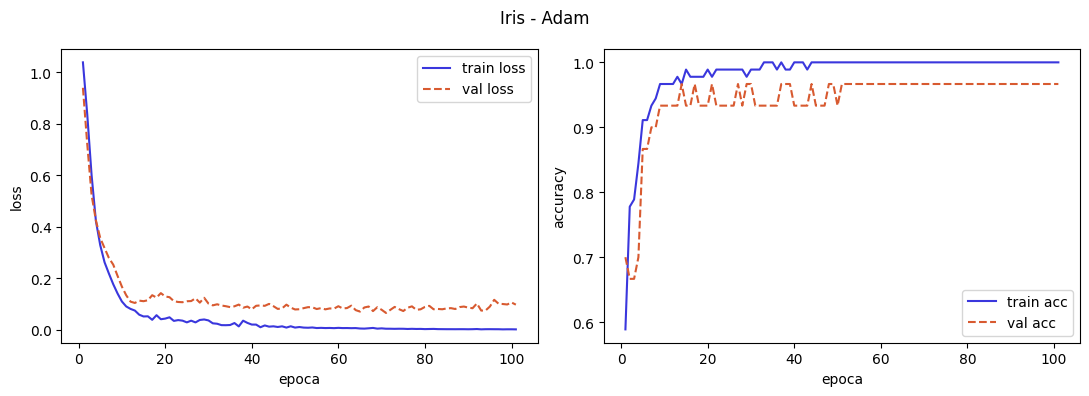

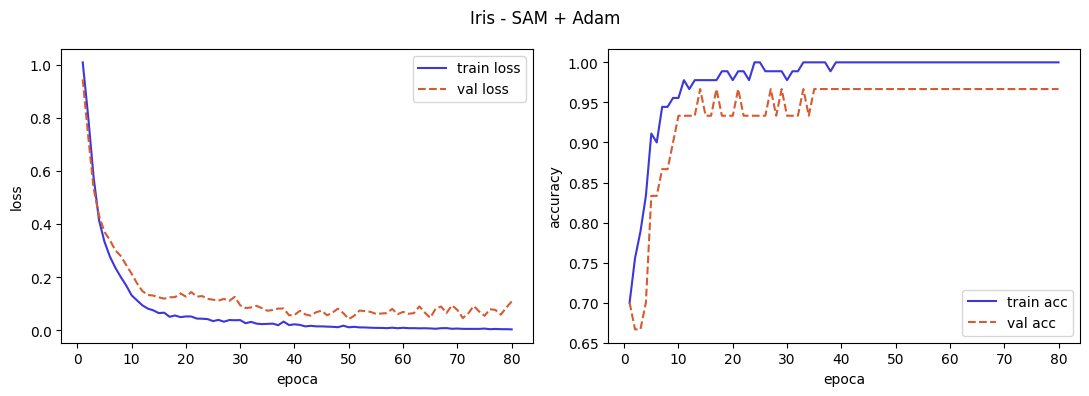

In [95]:
def train_model_multiclass(model, train_loader, val_loader, optimizer,
                            epochs, is_sam=False, patience=30):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for X, y in train_loader:
            if is_sam:
                out = model(X); loss = criterion(out, y); loss.backward()
                optimizer.first_step(zero_grad=True)
                out2 = model(X); loss2 = criterion(out2, y); loss2.backward()
                optimizer.second_step(zero_grad=True)
                with torch.no_grad():
                    out_log = model(X); loss_log = criterion(out_log, y)
            else:
                optimizer.zero_grad()
                out_log = model(X); loss_log = criterion(out_log, y)
                loss_log.backward(); optimizer.step()
            t_loss += loss_log.item()
            t_correct += (out_log.argmax(1) == y).sum().item()
            t_total += y.size(0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                out = model(X); loss = criterion(out, y)
                v_loss += loss.item()
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += y.size(0)

        avg_v = v_loss / len(val_loader)
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(avg_v)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(v_correct / v_total)

        if avg_v < best_val_loss:
            best_val_loss = avg_v
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    history['epochs_trained'] = len(history['train_loss'])
    return history


# Train Adam on Iris
set_seed(42)
modelo_adam_iris = MLP(input_dim=input_dim_iris, hidden_dims=[16, 16], output_dim=3)
opt_adam_iris = optim.Adam(modelo_adam_iris.parameters(), lr=0.01, weight_decay=1e-4)
hist_adam_iris = train_model_multiclass(modelo_adam_iris, train_loader_iris,
                                         val_loader_iris, opt_adam_iris, epochs=300)

# Train SAM on Iris
set_seed(42)
modelo_sam_iris = MLP(input_dim=input_dim_iris, hidden_dims=[16, 16], output_dim=3)
opt_sam_iris = SAM(modelo_sam_iris.parameters(), base_optimizer=optim.Adam,
                   lr=0.01, weight_decay=1e-4, rho=0.05)
hist_sam_iris = train_model_multiclass(modelo_sam_iris, train_loader_iris,
                                        val_loader_iris, opt_sam_iris,
                                        epochs=300, is_sam=True)

# Compute λ_max for both
criterion_iris = nn.CrossEntropyLoss()
lam_adam_iris = get_lambda_max(modelo_adam_iris, X_train_iris_t, y_train_iris_t,
                                criterion_iris, num_iterations=30, seed=42)
lam_sam_iris  = get_lambda_max(modelo_sam_iris,  X_train_iris_t, y_train_iris_t,
                                criterion_iris, num_iterations=30, seed=42)

print(f"Iris — Adam λ_max: {lam_adam_iris:.4f}")
print(f"Iris — SAM  λ_max: {lam_sam_iris:.4f}")

plot_history(hist_adam_iris, title="Iris - Adam")
plot_history(hist_sam_iris,  title="Iris - SAM + Adam")